In [1]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import StandardScaler
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency
import math

from sklearn.metrics import mean_squared_error 
from sklearn.metrics import mean_absolute_error 
from sklearn.metrics import r2_score 
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import train_test_split,cross_val_score, KFold,validation_curve,GridSearchCV
from sklearn.preprocessing import LabelEncoder

import joblib
from datetime import datetime


import ModelFunctions
names = dir(ModelFunctions)
function_names = [name for name in names if callable(getattr(ModelFunctions, name))]
print(function_names)

C:\Users\nining\AppData\Local\Temp\ipykernel_10668\305180208.py:4: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


['DecisionTreeRegressor', 'GridSearchCV', 'KFold', 'LabelEncoder', 'MinMaxScaler', 'ParameterGrid', 'RandomForestRegressor', 'StandardScaler', 'caculate_mrtrics', 'chi2_contingency', 'cross_val_score', 'datetime', 'mae', 'mean_squared_error', 'mse', 'plot_coarse_tuning', 'plot_feature_importance', 'plot_fine_tuning', 'r2', 'r2_score', 'rf_evaluate_parameter_grid', 'save_model', 'save_model_results', 'sort_features', 'split_data', 'standardize_column_names', 'train_test_split', 'validation_curve', 'wrapper_method']


# Decision Tree

In [3]:
file_name_rfl_mse = "rfl_gscv_mse_202402211610_max_depth-10-40-16_min_samples_leaf-2-9-8_min_samples_split-3-9-7_DT.pkl"
file_name_rfl_r2 = "rfl_gscv_r2_202402211610_max_depth-10-40-16_min_samples_leaf-2-9-8_min_samples_split-3-9-7_DT.pkl"
file_name_fso_mse = "fso_gscv_r2_202402211300_max_depth-10-40-16_min_samples_leaf-2-9-8_min_samples_split-3-9-7_DT.pkl"
file_name_fso_r2 = "fso_gscv_r2_202402211610_max_depth-10-40-16_min_samples_leaf-2-9-8_min_samples_split-3-9-7_DT.pkl"

# 加载文件
GS_mse_rfl = joblib.load(file_name_rfl_mse)
GS_r2_rfl = joblib.load(file_name_rfl_r2)
GS_mse_fso = joblib.load(file_name_fso_mse)
GS_r2_fso = joblib.load(file_name_fso_r2)

# 绘制图形
plt.figure(figsize=(12, 9))
plt.plot(GS_mse_rfl, label='RFL Grid Search MSE')
plt.plot(GS_r2_rfl, label='RFL Grid Search R^2')
plt.plot(GS_mse_fso, label='FSO Grid Search MSE')
plt.plot(GS_r2_fso, label='FSO Grid Search R^2')
plt.xlabel('Iterations')
plt.ylabel('Score')
plt.title('Grid Search Performance')
plt.legend()
plt.grid(True)
plt.show()

FileNotFoundError: [Errno 2] No such file or directory: 'fso_gscv_r2_202402211610_max_depth-10-40-16_min_samples_leaf-2-9-8_min_samples_split-3-9-7_DT.pkl'

# FSO Coarse Tuning

The file name indicates the hyperparameter range

train_mse best:
     n_estimators  max_depth  min_samples_leaf  min_samples_split  train_mse  \
142           300         30                 4                  3   0.265686   

     train_r2   val_mse   val_r2  
142  0.982698  0.774906  0.94849  
valid_mse best:
     n_estimators  max_depth  min_samples_leaf  min_samples_split  train_mse  \
142           300         30                 4                  3   0.265686   

     train_r2   val_mse   val_r2  
142  0.982698  0.774906  0.94849  


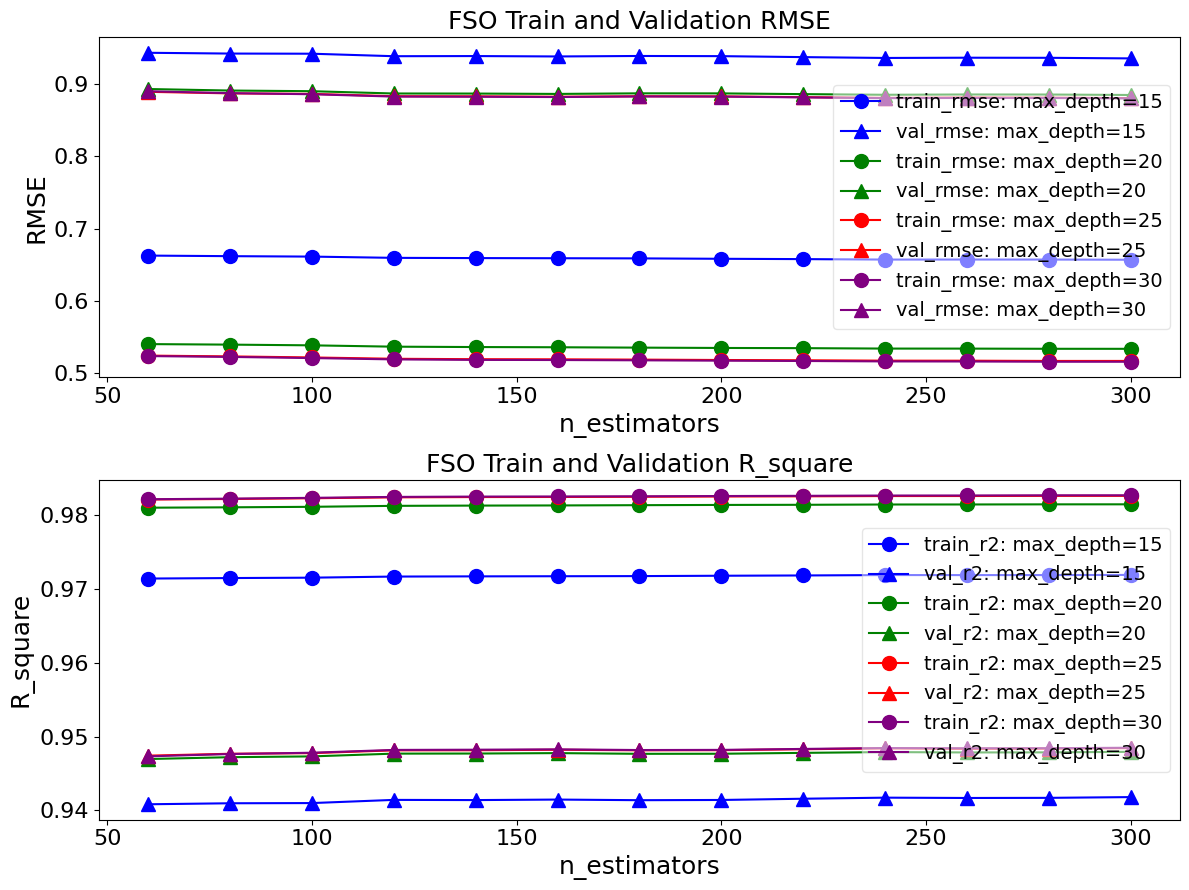

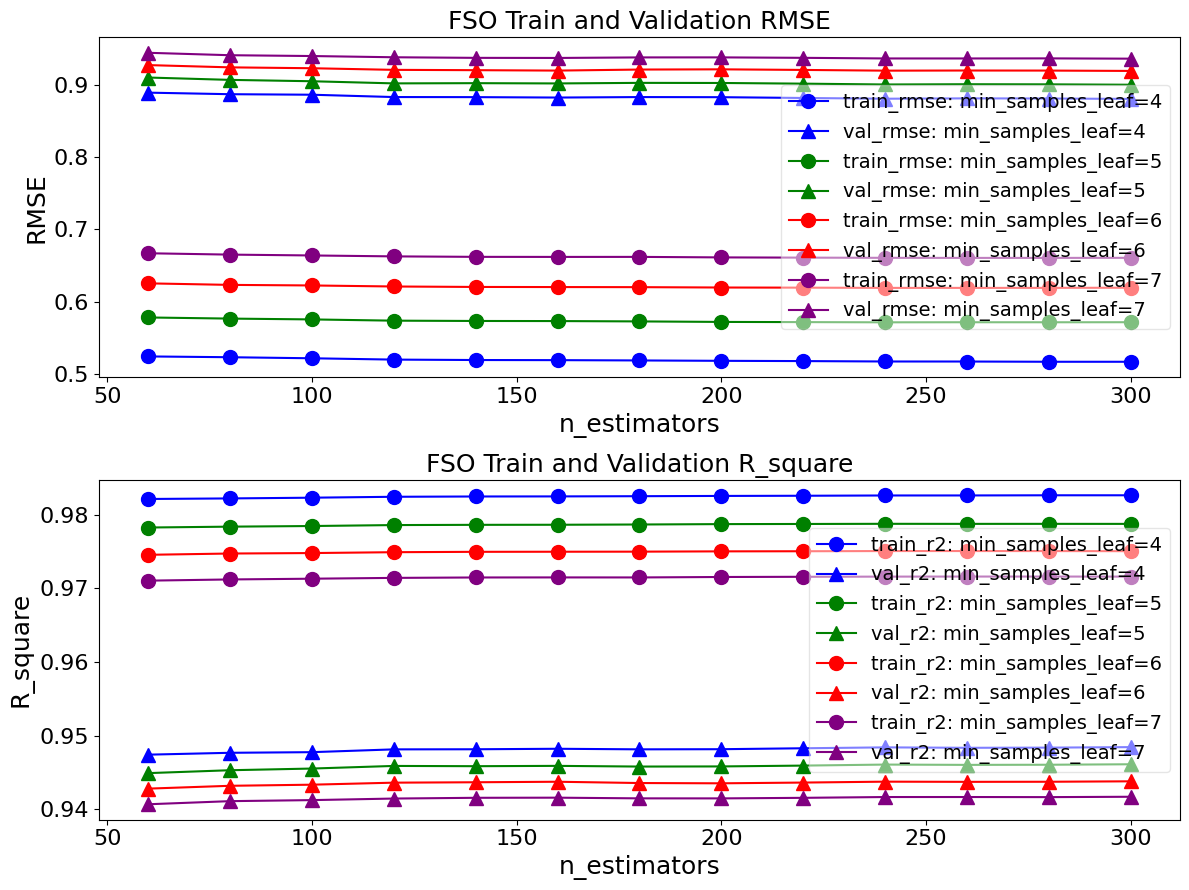

In [2]:
df1 = pd.read_csv("results_202402222107_n_estimators-100-300-11_max_depth-15-30-4_min_samples_leaf-4-7-4_min_samples_split-3-3-1_RFFSO.csv")
df2 = pd.read_csv("results_202402232258_n_estimators-60-80-2_max_depth-15-30-4_min_samples_leaf-4-7-4_min_samples_split-3-3-1_RF_fso_compensate.csv")
# all the hyperparameter tune in once time may cause time-consuming, 
# so split into two part to run and then concatenate the results of two parts.
df = pd.concat([df1, df2], axis=0)

min_train_mse_row = df[df['train_mse'] == df['train_mse'].min()]
print("train_mse best:")
print(min_train_mse_row)

min_valid_mse_row = df[df['val_mse'] == df['val_mse'].min()]
print("valid_mse best:")
print(min_valid_mse_row)

select_esti = df[(df['min_samples_leaf'] == 4) & (df['min_samples_split'] == 3)]

ModelFunctions.plot_coarse_tuning(select_esti, channel = 'FSO',group_column='max_depth', Xaxis='n_estimators',\
                    metrics='RMSE', metrics1='R_square',legend_loc="right")

select_esti = df[(df['max_depth'] == 25) & (df['min_samples_split'] == 3)]

ModelFunctions.plot_coarse_tuning(select_esti, channel = 'FSO',group_column='min_samples_leaf', Xaxis='n_estimators',\
                    metrics='RMSE', metrics1='R_square',legend_loc="right")

# FSO fine tunning

train_mse best:
    n_estimators  max_depth  min_samples_leaf  min_samples_split  train_mse  \
14           140         32                 1                  2   0.097016   

    train_r2   val_mse   val_r2  
14  0.993682  0.695622  0.95376  
valid_mse best:
   n_estimators  max_depth  min_samples_leaf  min_samples_split  train_mse  \
8           140         30                 1                  2   0.097202   

   train_r2   val_mse    val_r2  
8   0.99367  0.693993  0.953868  


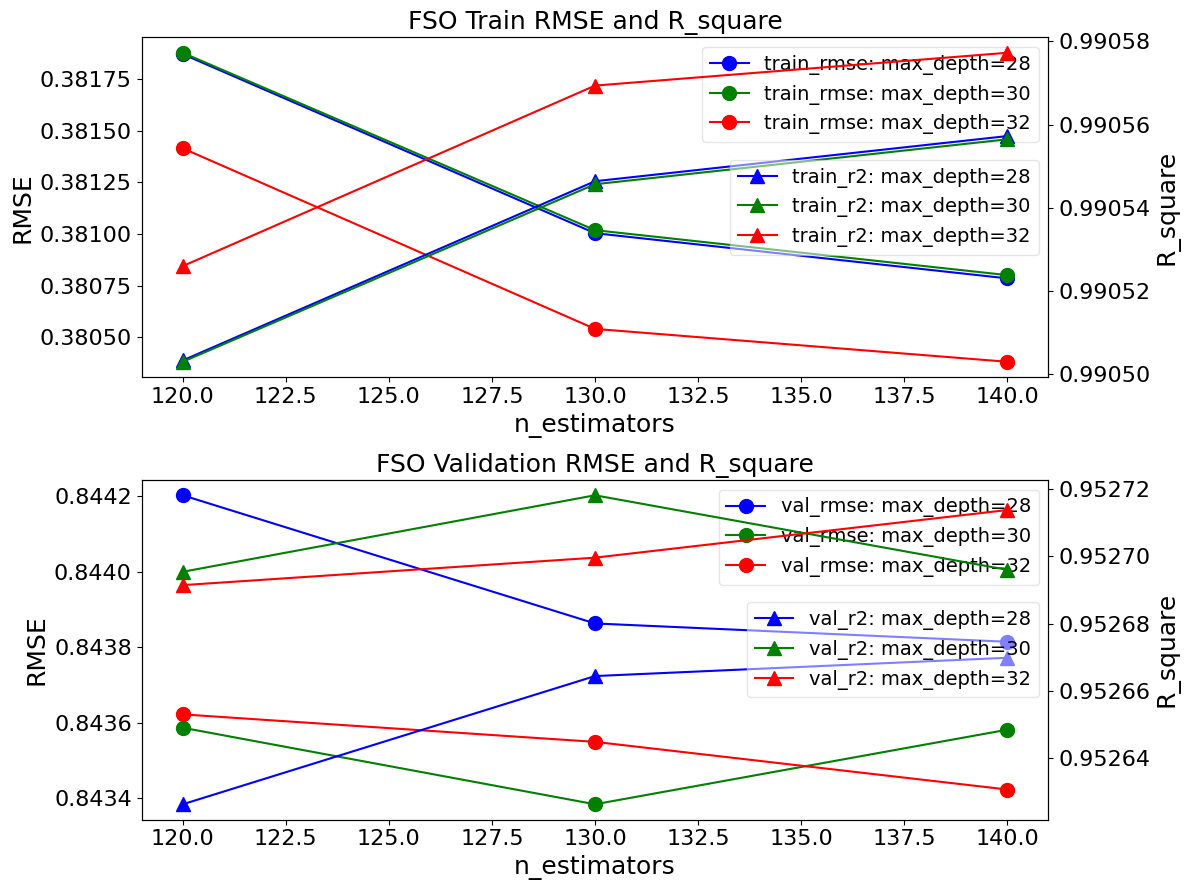

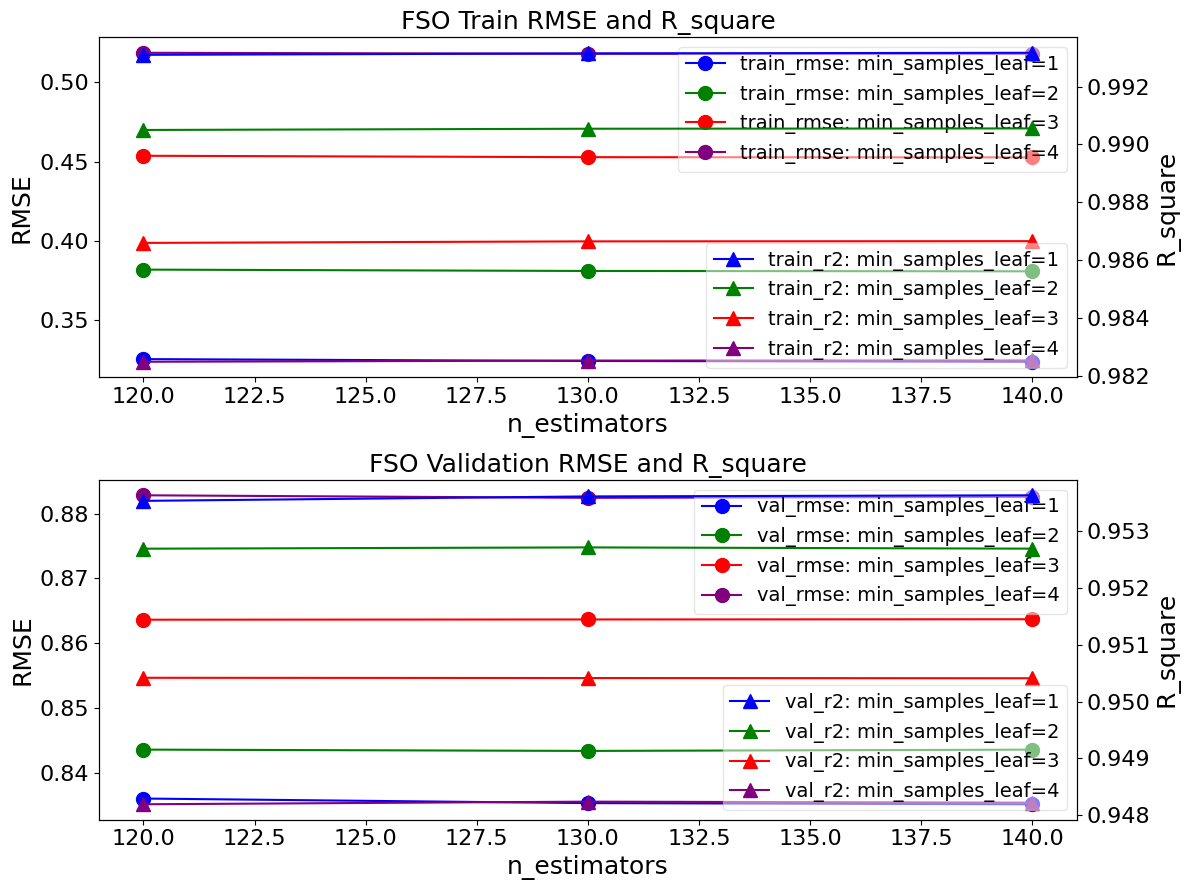

In [8]:
df1 = pd.read_csv("results_202402230144_n_estimators-120-140-3_max_depth-27-32-6_min_samples_leaf-2-5-4_min_samples_split-2-3-2_RFFSO.csv")
df2 = pd.read_csv('results_202402240942_n_estimators-120-140-3_max_depth-28-32-3_min_samples_leaf-1-1-1_min_samples_split-2-3-2_RF_FSO_compensate.csv')
df = pd.concat([df1,df2],axis = 0)

min_train_mse_row = df[df['train_mse'] == df['train_mse'].min()]
print("train_mse best:")
print(min_train_mse_row)

min_valid_mse_row = df[df['val_mse'] == df['val_mse'].min()]
print("valid_mse best:")
print(min_valid_mse_row)

select_esti = df[(df['min_samples_leaf'] == 2) & (df['min_samples_split'] == 3)]

ModelFunctions.plot_fine_tuning(select_esti, channel = 'FSO', lis=[28,30,32], group_column='max_depth', Xaxis='n_estimators',\
                            metrics='RMSE', metrics1='R_square',markersize = 10,\
                            legend_loc="upper right",legend_loc1="right")

select_esti = df[(df['max_depth'] == 30) & (df['min_samples_split'] == 3)]

ModelFunctions.plot_fine_tuning(select_esti, channel = 'FSO',lis=[1,2,3,4], group_column='min_samples_leaf', Xaxis='n_estimators',\
                            metrics='RMSE', metrics1='R_square',markersize = 10,\
                            legend_loc="upper right",legend_loc1="lower right")

# RFL coares tunning

In [4]:
df1 = pd.read_csv("results_202402231350_n_estimators-100-300-11_max_depth-15-30-4_min_samples_leaf-4-7-4_min_samples_split-3-3-1_RF_RFL.csv")
df2 = pd.read_csv("results_202402232230_n_estimators-60-80-2_max_depth-15-30-4_min_samples_leaf-4-7-4_min_samples_split-3-3-1_RF_rfl_compensate.csv")
df = pd.concat([df1,df2],axis = 0)

# 找出train_mse最大的一行
min_train_mse_row = df[df['train_mse'] == df['train_mse'].min()]

print("train_mse best:")
print(min_train_mse_row)

min_valid_mse_row = df[df['val_mse'] == df['val_mse'].min()]

print("valid_mse best:")
print(min_valid_mse_row)


train_mse best:
     n_estimators  max_depth  min_samples_leaf  min_samples_split  train_mse  \
142           300         30                 4                  3   0.109642   

     train_r2   val_mse    val_r2  
142  0.990759  0.321636  0.972601  
valid_mse best:
    n_estimators  max_depth  min_samples_leaf  min_samples_split  train_mse  \
88           100         25                 4                  3   0.111848   

    train_r2   val_mse    val_r2  
88  0.990573  0.319236  0.972805  


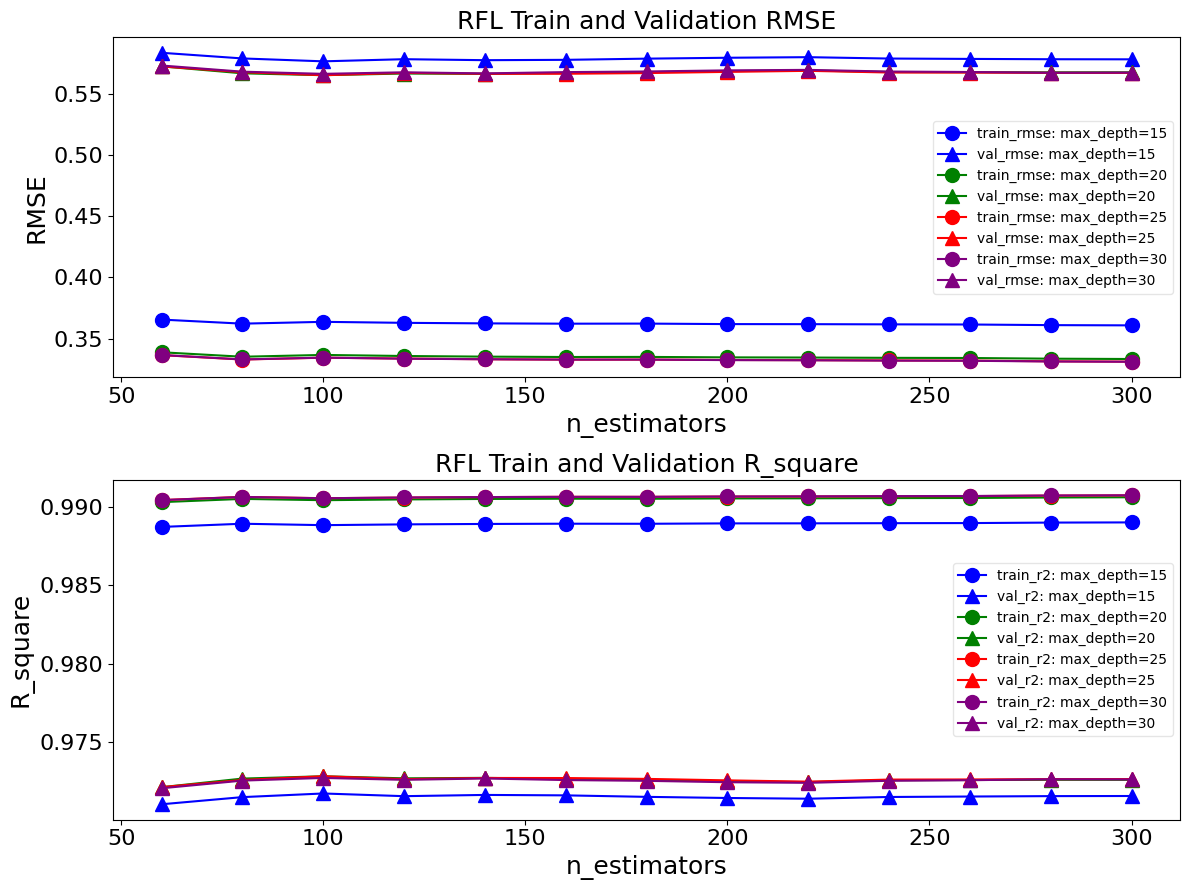

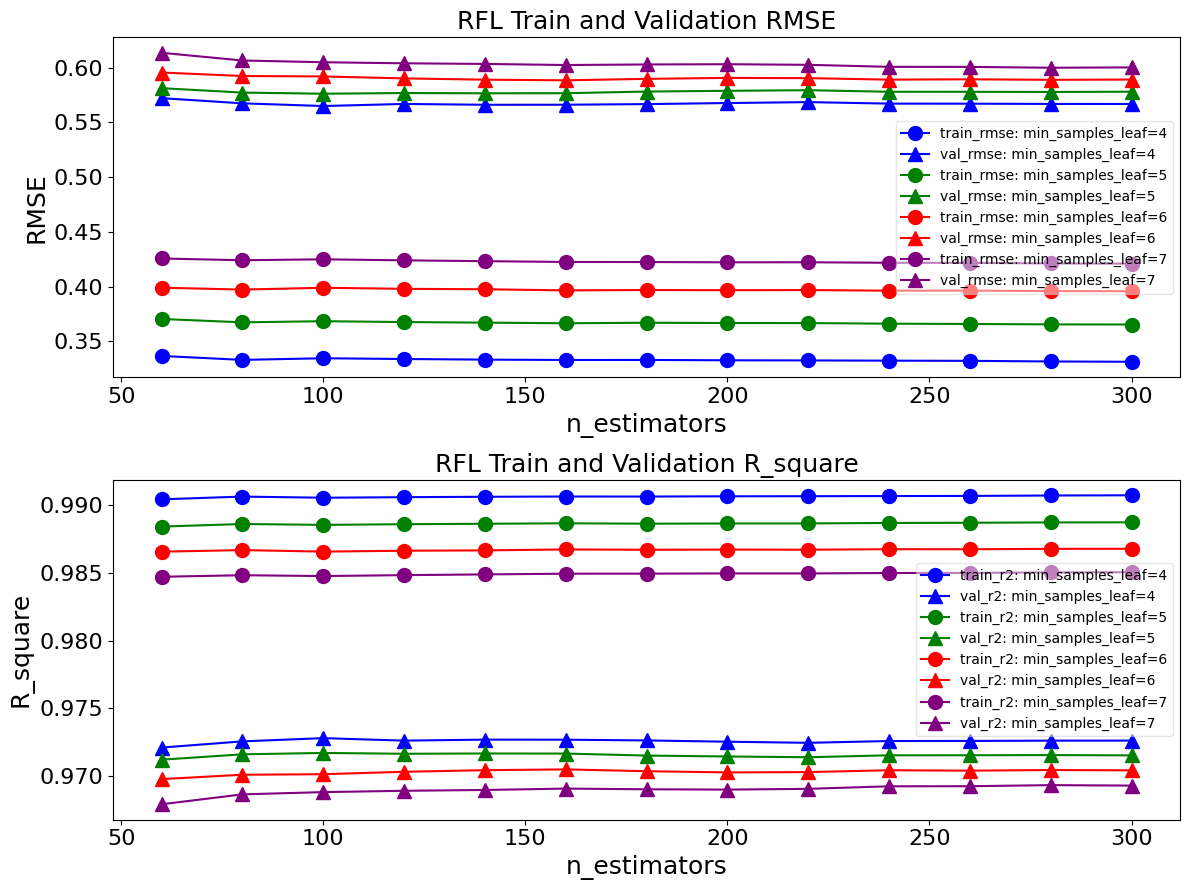

In [10]:

select_esti = df[(df['min_samples_leaf'] == 4) & (df['min_samples_split'] == 3)]

ModelFunctions.plot_coarse_tuning(select_esti, channel = 'RFL',group_column='max_depth', Xaxis='n_estimators',\
                    metrics='RMSE', metrics1='R_square',legend_loc="right")

select_esti = df[(df['max_depth'] == 25) & (df['min_samples_split'] == 3)]

ModelFunctions.plot_coarse_tuning(select_esti,channel = 'RFL', group_column='min_samples_leaf', Xaxis='n_estimators',\
                    metrics='RMSE', metrics1='R_square',legend_loc="right")


# RFL fine tunning

In [5]:
df = pd.read_csv('results_202402240404_n_estimators-100-140-5_max_depth-23-28-6_min_samples_leaf-1-4-4_min_samples_split-2-3-2_RF_rfl.csv')

min_train_mse_row = df[df['train_mse'] == df['train_mse'].min()]
print("train_mse best:")
print(min_train_mse_row)

min_valid_mse_row = df[df['val_mse'] == df['val_mse'].min()]
print("valid_mse best:")
print(min_valid_mse_row)

train_mse best:
     n_estimators  max_depth  min_samples_leaf  min_samples_split  train_mse  \
204           140         28                 1                  2   0.039252   

     train_r2   val_mse    val_r2  
204  0.996692  0.283803  0.975824  
valid_mse best:
    n_estimators  max_depth  min_samples_leaf  min_samples_split  train_mse  \
83           130         25                 1                  2   0.039881   

    train_r2   val_mse    val_r2  
83  0.996639  0.280065  0.976142  


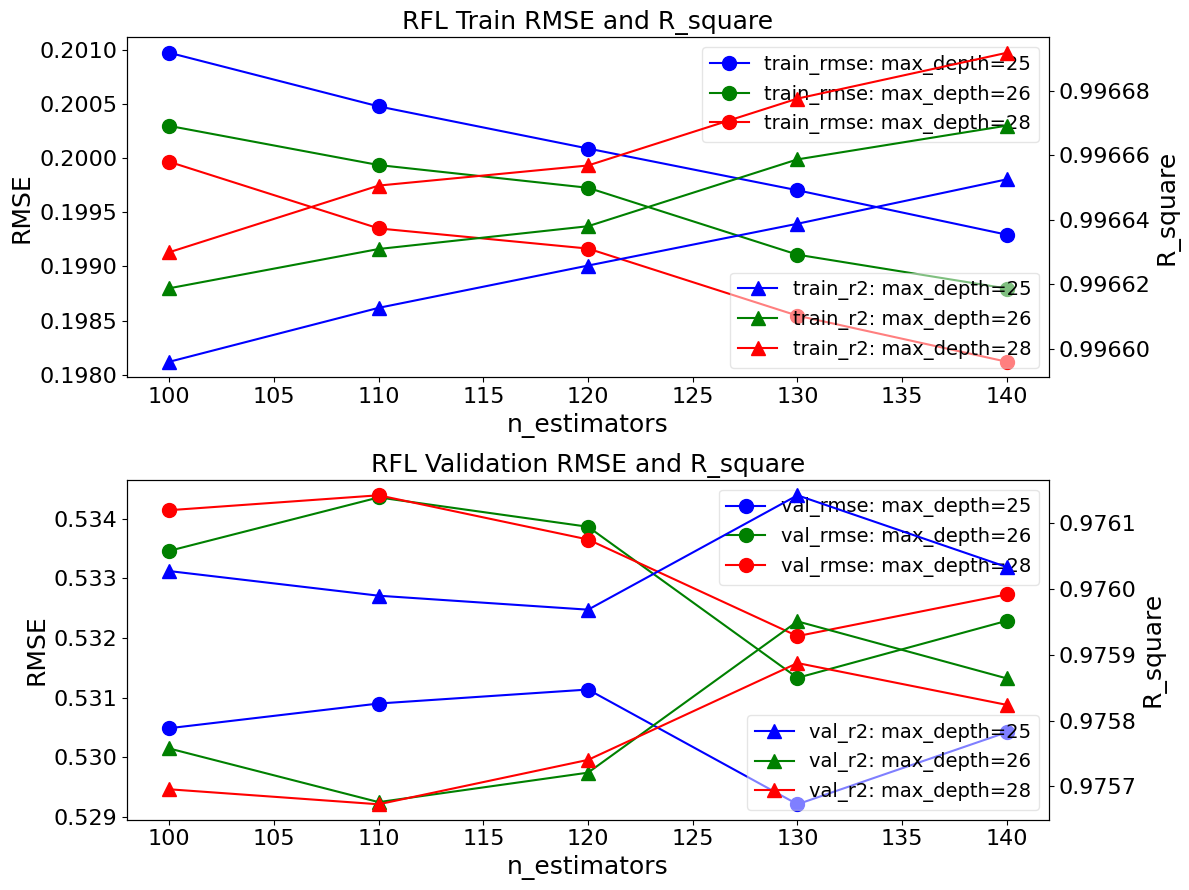

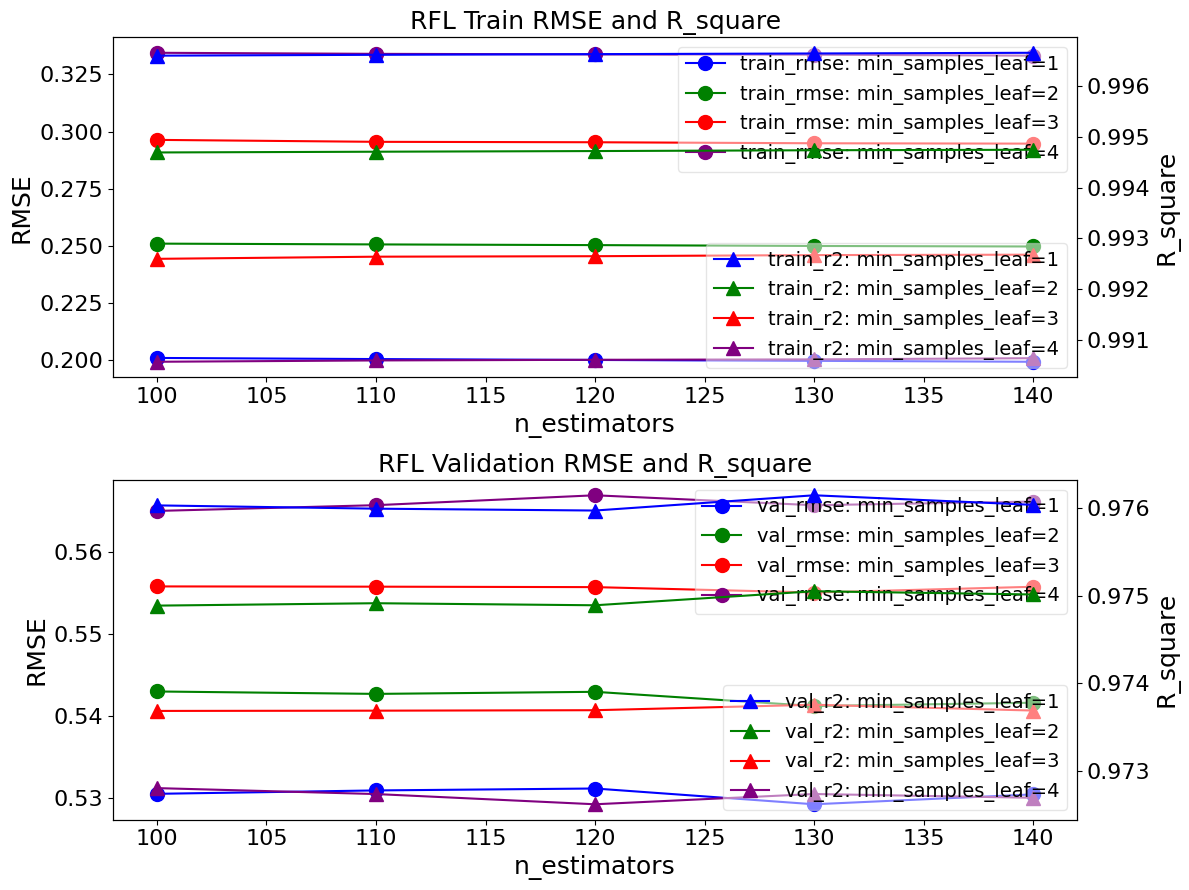

In [7]:

select_esti = df[(df['min_samples_leaf'] == 1) & (df['min_samples_split'] == 2)]

ModelFunctions.plot_fine_tuning(select_esti, channel = 'RFL',lis=[25,26,28], group_column='max_depth', Xaxis='n_estimators',\
                            metrics='RMSE', metrics1='R_square',markersize = 10,\
                            legend_loc="upper right",legend_loc1="lower right")

select_esti = df[(df['max_depth'] == 25) & (df['min_samples_split'] == 2)]

ModelFunctions.plot_fine_tuning(select_esti, channel = 'RFL',lis=[1,2,3,4], group_column='min_samples_leaf', Xaxis='n_estimators',\
                            metrics='RMSE', metrics1='R_square',markersize = 10,\
                            legend_loc="upper right",legend_loc1="lower right")

# Explore the feature importance

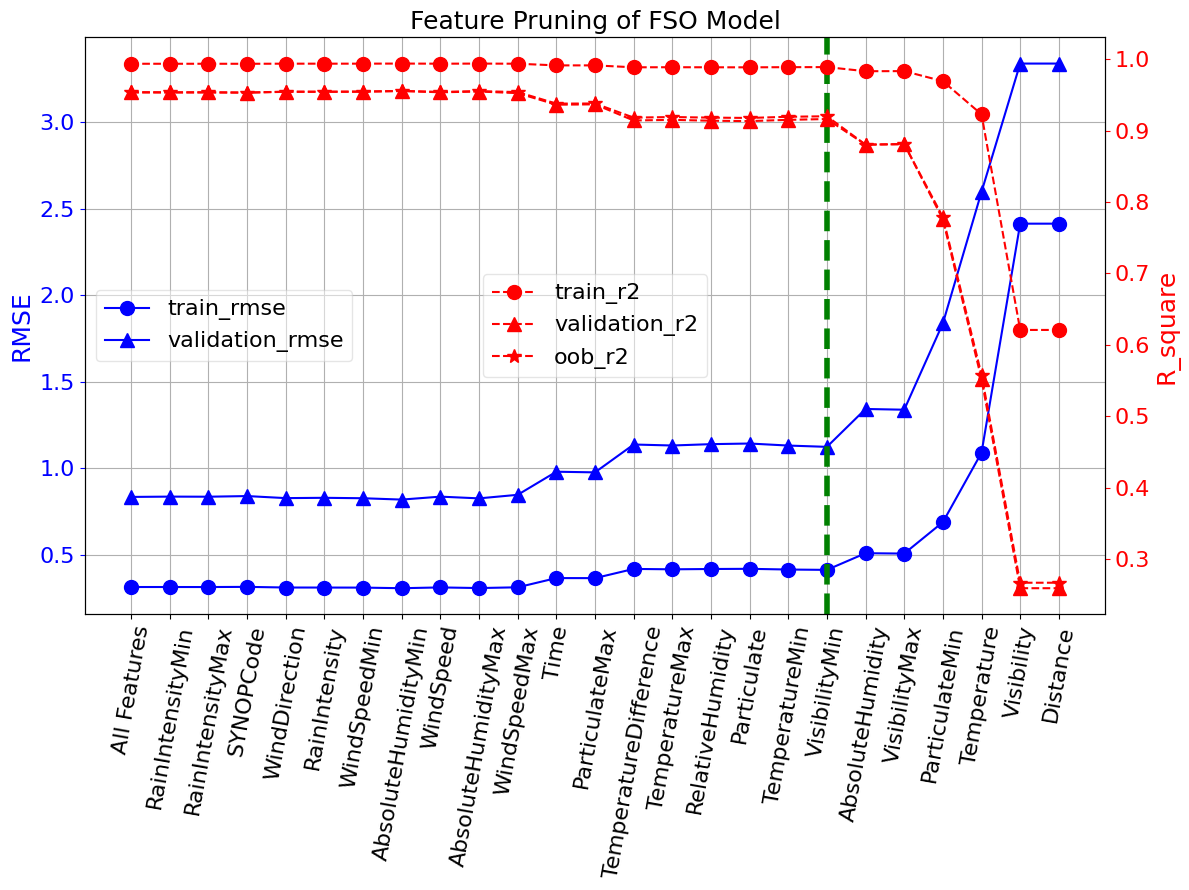

In [2]:
fso_rf_model = RandomForestRegressor(n_estimators = 130, max_depth=30, \
                                     min_samples_leaf = 1, random_state = 25,\
                                     min_samples_split =2, oob_score=True, n_jobs=6 )

df = pd.read_csv("FSO_130-30-1-2_feature_importance_wrapple.csv")

ModelFunctions.plot_feature_importance(df, threshold="VisibilityMin",channel="FSO", markersize=10, legend_loc="center left", legend_loc1="center")




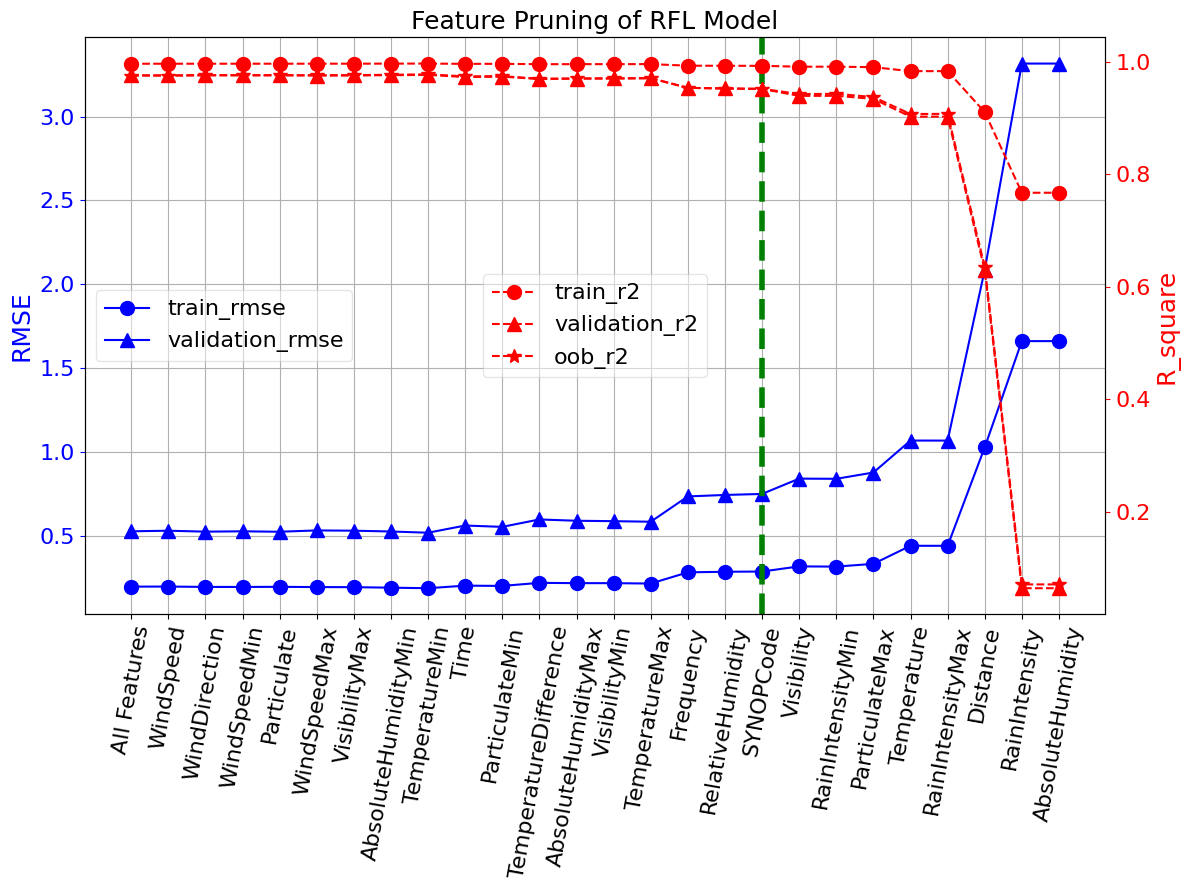

In [3]:
rfl_rf_model = RandomForestRegressor(n_estimators = 130, max_depth=25, \
                                     min_samples_leaf = 1, random_state = 25,\
                                     min_samples_split =2, oob_score=True, n_jobs=6 )

df = pd.read_csv("RFL_130-25-1-2_feature_importance_wrapple.csv")

ModelFunctions.plot_feature_importance(df, threshold="SYNOPCode", channel="RFL", markersize=10, legend_loc="center left", legend_loc1="center")